In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "pycadmk/cardiac-segmentation-in-mri"
)

print("Path to dataset files:", path)

100%|██████████| 152M/152M [00:01<00:00, 111MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pycadmk/cardiac-segmentation-in-mri/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:10]:
        print(f"{indent}  {file}")

1/
  cardiac/
    MANDATORY_CITATION.md
    volumes/
      patient105_frame10.nii
      patient108_frame01.nii
      patient066_frame11.nii
      patient088_frame12.nii
      patient097_frame11.nii
      patient046_frame01.nii
      patient041_frame01.nii
      patient102_frame13.nii
      patient138_frame10.nii
      patient054_frame01.nii
    segmentations/
      patient105_frame10.nii
      patient108_frame01.nii
      patient066_frame11.nii
      patient088_frame12.nii
      patient097_frame11.nii
      patient046_frame01.nii
      patient041_frame01.nii
      patient102_frame13.nii
      patient138_frame10.nii
      patient054_frame01.nii


In [ ]:
from pathlib import Path

dataset_root = Path(path) / "cardiac"

volumes_path = dataset_root / "volumes"
segmentations_path = dataset_root / "segmentations"

print("Volumes:", volumes_path)
print("Segmentations:", segmentations_path)

Volumes: /root/.cache/kagglehub/datasets/pycadmk/cardiac-segmentation-in-mri/versions/1/cardiac/volumes
Segmentations: /root/.cache/kagglehub/datasets/pycadmk/cardiac-segmentation-in-mri/versions/1/cardiac/segmentations


In [ ]:
volume_files = sorted(volumes_path.glob("*.nii"))
segmentation_files = sorted(segmentations_path.glob("*.nii"))

print("Number of MRI volumes:", len(volume_files))
print("Number of segmentation masks:", len(segmentation_files))

Number of MRI volumes: 300
Number of segmentation masks: 300


In [ ]:
print("First MRI files:")

for file in volume_files[:10]:
    print(file.name)

print("\nFirst segmentation files:")

for file in segmentation_files[:10]:
    print(file.name)

First MRI files:
patient001_frame01.nii
patient001_frame12.nii
patient002_frame01.nii
patient002_frame12.nii
patient003_frame01.nii
patient003_frame15.nii
patient004_frame01.nii
patient004_frame15.nii
patient005_frame01.nii
patient005_frame13.nii

First segmentation files:
patient001_frame01.nii
patient001_frame12.nii
patient002_frame01.nii
patient002_frame12.nii
patient003_frame01.nii
patient003_frame15.nii
patient004_frame01.nii
patient004_frame15.nii
patient005_frame01.nii
patient005_frame13.nii


In [ ]:
volume_names = {file.name for file in volume_files}
segmentation_names = {file.name for file in segmentation_files}

print("MRI files without masks:")
print(volume_names - segmentation_names)

print("\nMasks without MRI files:")
print(segmentation_names - volume_names)

MRI files without masks:
set()

Masks without MRI files:
set()


In [69]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import torchvision
from pathlib import Path
from tqdm.notebook import tqdm
import random
import torch.nn as nn
import torch.nn.functional as f
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from google.colab import files

In [ ]:
sample_path = volume_files[0]

sample_mask_path = segmentations_path / sample_path.name

print("MRI:", sample_path)
print("Mask:", sample_mask_path)

MRI: /root/.cache/kagglehub/datasets/pycadmk/cardiac-segmentation-in-mri/versions/1/cardiac/volumes/patient001_frame01.nii
Mask: /root/.cache/kagglehub/datasets/pycadmk/cardiac-segmentation-in-mri/versions/1/cardiac/segmentations/patient001_frame01.nii


In [ ]:
data = nib.load(sample_path)
label = nib.load(sample_mask_path)

mri = data.get_fdata()
mask = label.get_fdata().astype(np.uint8)

print("MRI shape:", mri.shape)
print("Mask shape:", mask.shape)

MRI shape: (216, 256, 10)
Mask shape: (216, 256, 10)


In [ ]:
print("Affine:")
print(data.affine)

print("\nOrientation:")
print(nib.aff2axcodes(data.affine))

Affine:
[[-1.5625  0.      0.     -0.    ]
 [ 0.     -1.5625  0.     -0.    ]
 [ 0.      0.     10.      0.    ]
 [ 0.      0.      0.      1.    ]]

Orientation:
('L', 'P', 'S')


In [ ]:
print("Voxel size:")
print(data.header.get_zooms())

Voxel size:
(np.float32(1.5625), np.float32(1.5625), np.float32(10.0))


In [ ]:
print("Minimum mask value:", mask.min())
print("Maximum mask value:", mask.max())

print("Unique mask values:")
print(np.unique(mask))

Minimum mask value: 0
Maximum mask value: 3
Unique mask values:
[0 1 2 3]


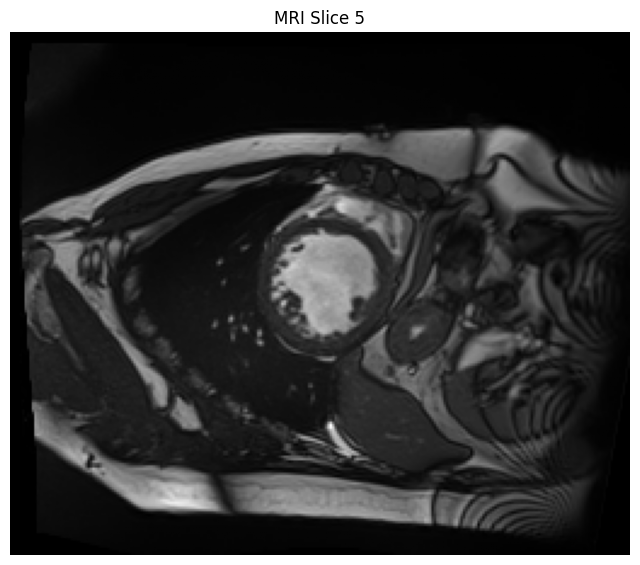

In [ ]:
slice_index = mri.shape[2] // 2

plt.figure(figsize=(8, 8))
plt.imshow(mri[:, :, slice_index], cmap="gray")
plt.axis("off")
plt.title(f"MRI Slice {slice_index}")
plt.show()

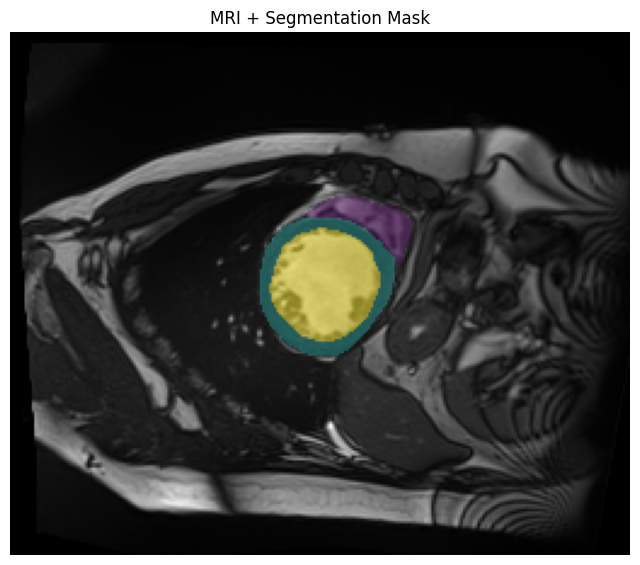

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(mri[:, :, slice_index], cmap="gray")
mask_ = np.ma.masked_where(
    mask[:, :, slice_index] == 0, mask[:, :, slice_index]
)
plt.imshow(mask_, alpha=0.5)
plt.axis("off")
plt.title("MRI + Segmentation Mask")
plt.show()

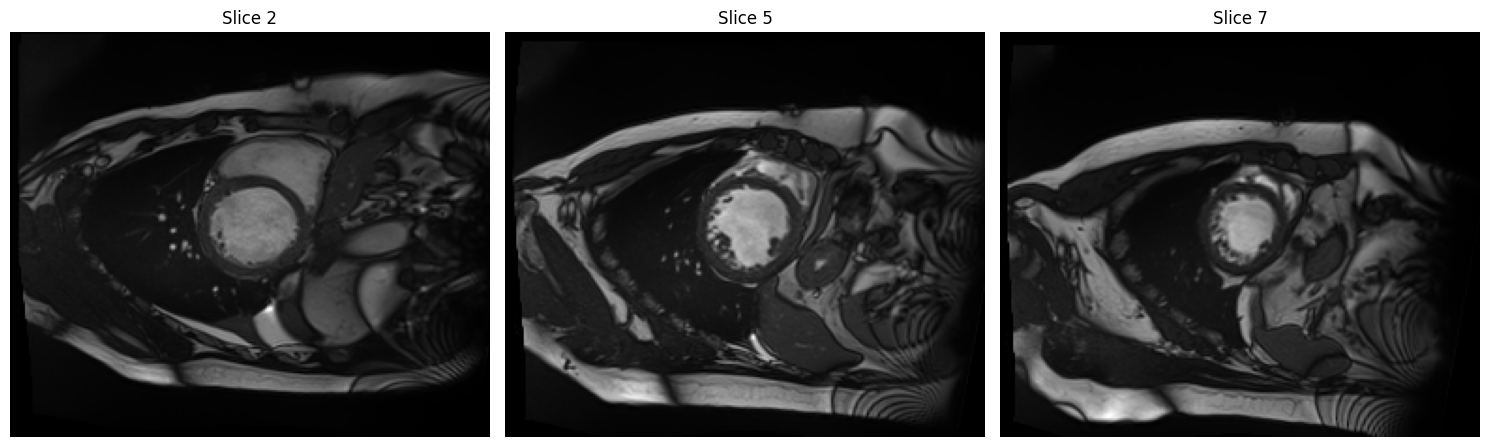

In [ ]:
fig, axis = plt.subplots(1, 3, figsize=(15, 15))

indices = [
    mri.shape[2] // 4,
    mri.shape[2] // 2,
    3 * mri.shape[2] // 4
]

for ax, index in zip(axis, indices):
    ax.imshow(mri[:, :, index], cmap="gray")
    ax.axis("off")
    ax.set_title(f"Slice {index}")

plt.tight_layout()
plt.show()

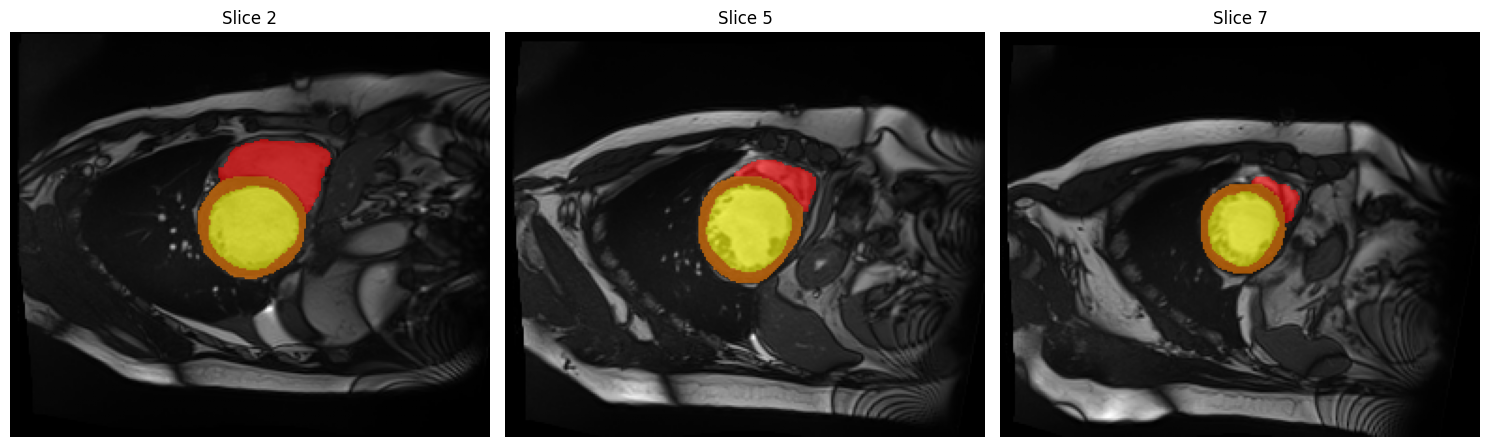

In [ ]:
fig , axis = plt.subplots(1, 3, figsize=(15, 15))

for ax, index in zip(axis, indices):
    ax.imshow(mri[:, :, index], cmap="gray")
    mask_ = np.ma.masked_where(
        mask[:, :, index] == 0,
        mask[:, :, index]
    )

    ax.imshow(mask_, alpha=0.6, cmap="autumn")
    ax.axis("off")
    ax.set_title(f"Slice {index}")

plt.tight_layout()
plt.show()

In [ ]:
def normalize(full_volume):
    mu = full_volume.mean()
    std = np.std(full_volume)
    normalized = (full_volume - mu) / std
    return normalized

In [ ]:
def standardize(normalized):
  standardized = (normalized - normalized.min()) / (normalized.max() - normalized.min())

  return standardized

In [ ]:
normalized_mri = normalize(mri)
standardized_mri = standardize(normalized_mri)

print("Original:")
print(mri.min(), mri.max())

print("\nNormalized:")
print(normalized_mri.min(), normalized_mri.max())

print("\nStandardized:")
print(standardized_mri.min(), standardized_mri.max())

Original:
0.0 658.0

Normalized:
-0.8793147444081065 6.5435349073062

Standardized:
0.0 1.0


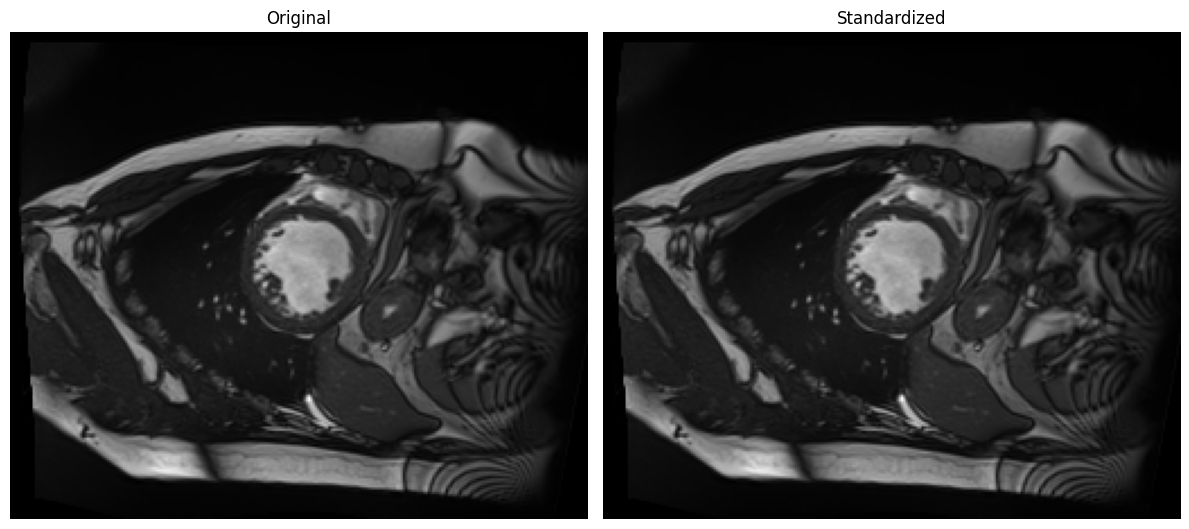

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(12, 6))

axis[0].imshow(mri[:, :, slice_index], cmap="gray")
axis[0].set_title("Original")
axis[0].axis("off")

axis[1].imshow(standardized_mri[:, :, slice_index], cmap="gray")
axis[1].set_title("Standardized")
axis[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [ ]:
volume_files = sorted(volumes_path.glob("*.nii"))
patient_ids = sorted({
    file.name.split("_")[0]
    for file in volume_files
})

print("Number of patients:", len(patient_ids))
print("First patients:", patient_ids[:10])

Number of patients: 150
First patients: ['patient001', 'patient002', 'patient003', 'patient004', 'patient005', 'patient006', 'patient007', 'patient008', 'patient009', 'patient010']


In [ ]:
random.seed(SEED)

patient = patient_ids.copy()
random.shuffle(patient)

split_index = int(0.8 * len(patient))

train_patients = sorted(patient[:split_index])
val_patients = sorted(patient[split_index:])

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))

print("\nTrain:", train_patients[:5])
print("Validation:", val_patients[:5])

Train patients: 120
Validation patients: 30

Train: ['patient001', 'patient003', 'patient004', 'patient005', 'patient006']
Validation: ['patient002', 'patient007', 'patient008', 'patient009', 'patient021']


In [ ]:
train_volumes = [
    volumes_path / f"{patient}_frame01.nii"
    for patient in train_patients
    if (volumes_path / f"{patient}_frame01.nii").exists()
]

val_volumes = [
    volumes_path / f"{patient}_frame01.nii"
    for patient in val_patients
    if (volumes_path / f"{patient}_frame01.nii").exists()
]

print("Train volumes:", len(train_volumes))
print("Validation volumes:", len(val_volumes))

Train volumes: 120
Validation volumes: 29


In [ ]:
sample_volume_path = train_volumes[0]
sample_mask_path = segmentations_path / sample_volume_path.name

sample_volume = nib.load(sample_volume_path).get_fdata()
sample_mask = nib.load(sample_mask_path).get_fdata()

print("Volume shape:", sample_volume.shape)
print("Mask shape:", sample_mask.shape)
print("Volume dtype:", sample_volume.dtype)
print("Mask dtype:", sample_mask.dtype)

Volume shape: (216, 256, 10)
Mask shape: (216, 256, 10)
Volume dtype: float64
Mask dtype: float64


In [ ]:
train_slice_count = sum(
    nib.load(path).shape[-1]
    for path in train_volumes
)

val_slice_count = sum(
    nib.load(path).shape[-1]
    for path in val_volumes
)

print("Train slices:", train_slice_count)
print("Validation slices:", val_slice_count)

Train slices: 1203
Validation slices: 279


In [ ]:
def create_slice_index(volume_files):
    slice_index = []

    for volume_path in volume_files:
        shape = nib.load(volume_path).shape

        for slice_idx in range(shape[-1]):
            slice_index.append((volume_path, slice_idx))

    return slice_index


train_index = create_slice_index(train_volumes)
val_index = create_slice_index(val_volumes)

print("Train samples:", len(train_index))
print("Validation samples:", len(val_index))

Train samples: 1203
Validation samples: 279


In [ ]:
def normalize_slice(image):
  image = image.astype(np.float32)
  mean = image.mean()
  std = image.std()
  if std > 0:
    image = (image - mean) / std
  else:
    image = image - mean

  return image

In [ ]:
class CardiacMRIDataset(Dataset):
    def __init__(
        self,
        slice_index,
        image_size=(128, 128),
        augment=False
    ):
        self.slice_index = slice_index
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        volume_path, slice_idx = self.slice_index[idx]
        mask_path = masks_path / volume_path.name

        volume = nib.load(volume_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()

        image = volume[:, :, slice_idx]
        mask = mask[:, :, slice_idx]

        image = normalize_slice(image)

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).long()

        image = image.unsqueeze(0)

        image = F.interpolate(
            image.unsqueeze(0),
            size=self.image_size,
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        mask = F.interpolate(
            mask.unsqueeze(0).unsqueeze(0).float(),
            size=self.image_size,
            mode="nearest"
        ).squeeze().long()

        return image, mask

In [ ]:
train_dataset = CardiacMRIDataset(
    train_index,
    image_size=(128, 128),
    augment=False
)

val_dataset = CardiacMRIDataset(
    val_index,
    image_size=(128, 128),
    augment=False
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 1203
Validation dataset: 279


In [ ]:
masks_path = segmentations_path
train_dataset = CardiacMRIDataset(
    train_index,
    image_size=(128, 128),
    augment=False
)

val_dataset = CardiacMRIDataset(
    val_index,
    image_size=(128, 128),
    augment=False
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 1203
Validation dataset: 279


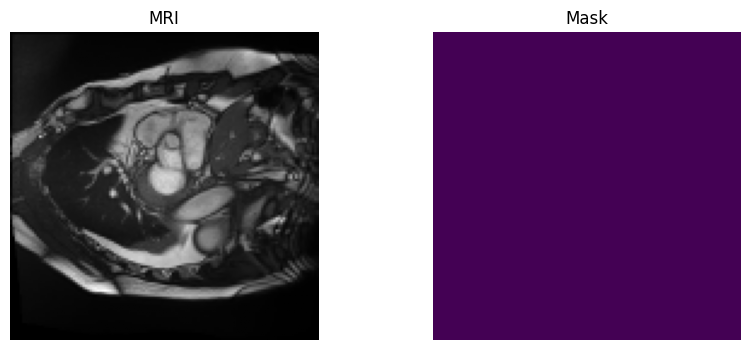

In [ ]:
image, mask = train_dataset[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="viridis")
plt.title("Mask")
plt.axis("off")

plt.show()

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 151
Validation batches: 35


In [ ]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

Images shape: torch.Size([8, 1, 128, 128])
Masks shape: torch.Size([8, 128, 128])
Image dtype: torch.float32
Mask dtype: torch.int64


In [ ]:
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.block = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.block(x)

In [ ]:
class UNet(nn.Module):
  def __init__(self, num_classes=4):
    super().__init__()
    self.enc1 = DoubleConv(1, 16)
    self.enc2 = DoubleConv(16, 32)
    self.enc3 = DoubleConv(32, 64)
    self.enc4 = DoubleConv(64, 128)

    self.pool = nn.MaxPool2d(2)

    self.bottleneck = DoubleConv(128, 256)

    self.dec4 = DoubleConv(256 + 128, 128)
    self.dec3 = DoubleConv(128 + 64, 64)
    self.dec2 = DoubleConv(64 + 32, 32)
    self.dec1 = DoubleConv(32 + 16, 16)

    self.out = nn.Conv2d(16, num_classes, kernel_size=1)

  def forward(self, x):
    # Encoder
    e1 = self.enc1(x)
    p1 = self.pool(e1)

    e2 = self.enc2(p1)
    p2 = self.pool(e2)

    e3 = self.enc3(p2)
    p3 = self.pool(e3)

    e4 = self.enc4(p3)
    p4 = self.pool(e4)

    # Bottleneck
    b = self.bottleneck(p4)

    # Decoder
    d4 = F.interpolate(b, size=e4.shape[-2:], mode="bilinear", align_corners=False)
    d4 = torch.cat([d4, e4], dim=1)
    d4 = self.dec4(d4)

    d3 = F.interpolate(d4, size=e3.shape[-2:], mode="bilinear", align_corners=False)
    d3 = torch.cat([d3, e3], dim=1)
    d3 = self.dec3(d3)

    d2 = F.interpolate(d3, size=e2.shape[-2:], mode="bilinear", align_corners=False)
    d2 = torch.cat([d2, e2], dim=1)
    d2 = self.dec2(d2)

    d1 = F.interpolate(d2, size=e1.shape[-2:], mode="bilinear", align_corners=False)
    d1 = torch.cat([d1, e1], dim=1)
    d1 = self.dec1(d1)

    return self.out(d1)

In [ ]:
NUM_CLASSES = 4

model = UNet(num_classes=NUM_CLASSES)

print(model)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc4): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128,

In [ ]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Total parameters: {total_params:,}")

Total parameters: 1,962,388


In [ ]:
sample_images, sample_masks = next(iter(train_loader))

with torch.no_grad():
    output = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([8, 1, 128, 128])
Output shape: torch.Size([8, 4, 128, 128])


In [ ]:
def multiclass_dice_score(
    logits,
    targets,
    num_classes=4,
    exclude_background=True):

    predictions = torch.argmax(logits, dim=1)
    start_class = 1 if exclude_background else 0
    dice_scores = []
    for class_id in range(start_class, num_classes):
      pred_class = (predictions == class_id).float()
      target_class = (targets == class_id).float()
      intersection = torch.sum(pred_class * target_class)
      union = (pred_class * target_class).sum()
      denominator = pred_class.sum() + target_class.sum()

      if denominator == 0:
        continue

      dice = (2 * intersection + 1e-8) / (denominator + 1e-8)
      dice_scores.append(dice)

    if len(dice_scores) == 0:
      return torch.tensor(1.0, device=logits.device)

    return torch.stack(dice_scores).mean()

In [ ]:
class DiceLoss(nn.Module):

  def __init__(self, num_classes=4):
    super().__init__()
    self.num_classes = num_classes

  def forward(self, logits, targets):
    probabilities = torch.softmax(
        logits,
        dim=1
    )

    total_dice = 0.0
    count = 0

    for class_id in range(1, self.num_classes):
      prediction = probabilities[:, class_id]
      target = (targets == class_id).float()

      intersection = (
          prediction * target
      ).sum(dim=(1, 2))

      denominator = prediction.sum(dim=(1, 2)) + target.sum(dim=(1, 2))

      dice = (2 * intersection + 1e-8) / (denominator + 1e-8)
      total_dice += dice.mean()
      count += 1

    return 1 - total_dice / count

In [ ]:
cross_entropy = nn.CrossEntropyLoss()
dice_loss = DiceLoss(NUM_CLASSES)

def combined_loss(logits, targets):
  ce = cross_entropy(logits, targets)
  dice = dice_loss(logits, targets)

  return ce + dice

In [ ]:
loss = combined_loss(output, sample_masks)

print("Loss:", loss.item())

Loss: 2.2144856452941895


In [ ]:
device = "cpu"

model = model.to(device)

print("Device:", device)

Device: cpu


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_one_epoch(model, loader, optimizer, device):

    model.train()

    running_loss = 0.0
    running_dice = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        dice = multiclass_dice_score(outputs, masks, NUM_CLASSES)

        running_loss += loss.item()
        running_dice += dice.item()

    epoch_loss = (running_loss / len(loader))

    epoch_dice = (running_dice / len(loader))

    return epoch_loss, epoch_dice

In [ ]:
def validate_one_epoch(model, loader, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs, masks)

            dice = multiclass_dice_score(outputs, masks, NUM_CLASSES)

            running_loss += loss.item()
            running_dice += dice.item()

    epoch_loss = (running_loss / len(loader))
    epoch_dice = (running_dice / len(loader))

    return epoch_loss, epoch_dice

In [ ]:
EPOCHS = 3

train_losses = []
val_losses = []

train_dices = []
val_dices = []

best_val_dice = 0.0

for epoch in range(EPOCHS):
    train_loss, train_dice = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss, val_dice = validate_one_epoch(
        model,
        val_loader,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_dices.append(train_dice)
    val_dices.append(val_dice)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )

    if val_dice > best_val_dice:

        best_val_dice = val_dice

        torch.save(model.state_dict(), "cardiac_unet_best.pth")

        print("Best model saved.")

Epoch 1/3 | Train Loss: 0.9012 | Train Dice: 0.1615 | Val Loss: 0.6970 | Val Dice: 0.5129
Best model saved.
Epoch 2/3 | Train Loss: 0.5850 | Train Dice: 0.6062 | Val Loss: 0.5130 | Val Dice: 0.6631
Best model saved.
Epoch 3/3 | Train Loss: 0.4360 | Train Dice: 0.7275 | Val Loss: 0.4034 | Val Dice: 0.7622
Best model saved.


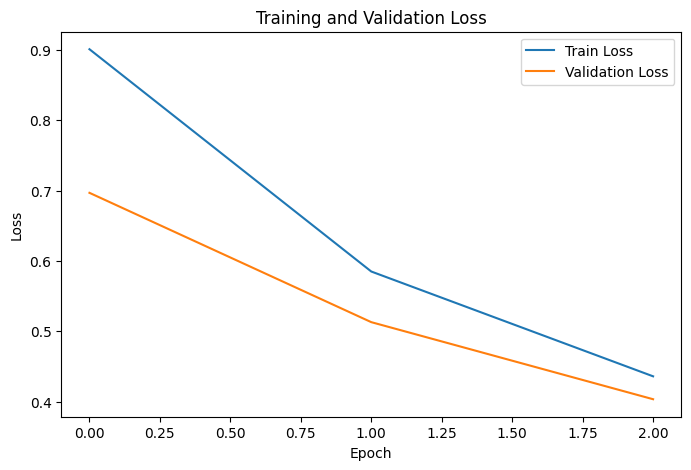

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

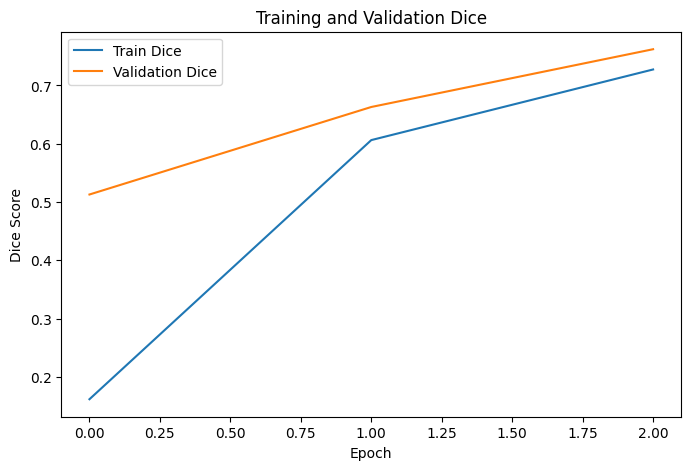

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_dices, label="Train Dice")

plt.plot(val_dices, label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice")
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load("cardiac_unet_best.pth", map_location=device))

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [ ]:
sample_image, sample_mask = val_dataset[0]

input_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():

    prediction = model(input_image)

predicted_mask = torch.argmax(prediction, dim=1).squeeze(0)

print("Prediction shape:", predicted_mask.shape)
print(
    "Predicted classes:",
    torch.unique(predicted_mask)
)

Prediction shape: torch.Size([128, 128])
Predicted classes: tensor([0, 1, 2, 3])


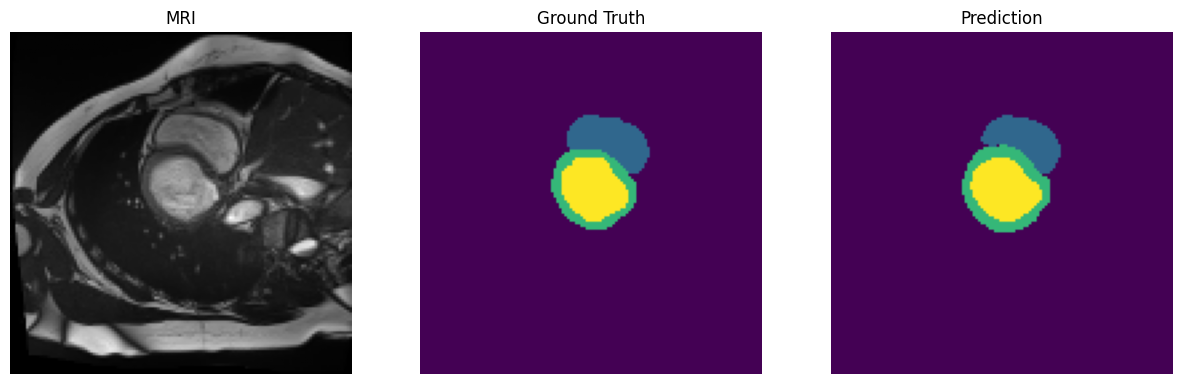

In [64]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)

plt.imshow(sample_image.squeeze(), cmap="gray")

plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)

plt.imshow(sample_mask, cmap="viridis")

plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)

plt.imshow(predicted_mask.cpu(), cmap="viridis")

plt.title("Prediction")
plt.axis("off")
plt.show()

In [63]:
sample_dice = multiclass_dice_score(
    prediction,
    sample_mask.unsqueeze(0),
    NUM_CLASSES
)

print(
    f"Sample Dice Score: {sample_dice.item():.4f}"
)

Sample Dice Score: 0.9098


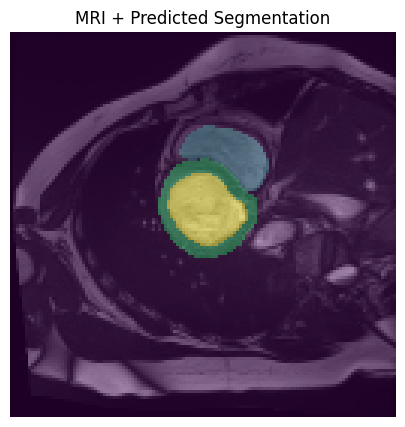

In [65]:
plt.figure(figsize=(10, 5))

plt.imshow(sample_image.squeeze(), cmap="gray")

plt.imshow(predicted_mask.cpu(), cmap="viridis", alpha=0.45)

plt.title("MRI + Predicted Segmentation")
plt.axis("off")
plt.show()

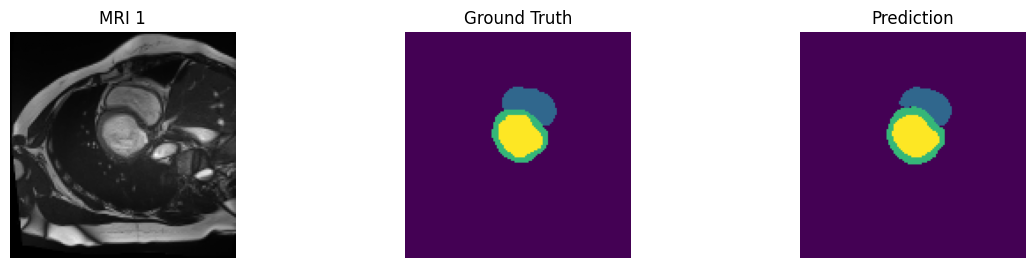

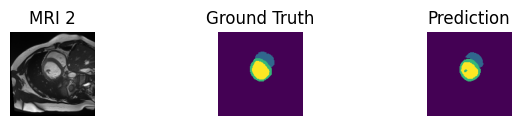

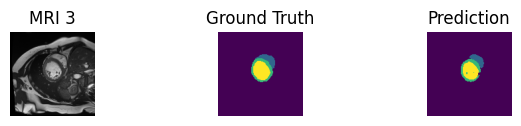

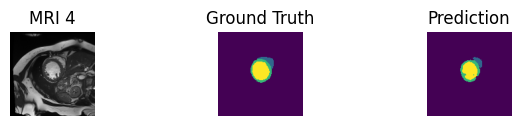

In [67]:
num_samples = 4

plt.figure(figsize=(12, 10))

for i in range(num_samples):
  image, mask = val_dataset[i]

  with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))

  predicted = torch.argmax(output, dim=1).squeeze(0)

  plt.subplot(num_samples, 3, i * 3 + 1)
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(f"MRI {i + 1}")
  plt.axis("off")

  plt.subplot(num_samples, 3, i * 3 + 2)

  plt.imshow(mask, cmap="viridis")
  plt.title("Ground Truth")
  plt.axis("off")

  plt.subplot(num_samples, 3, i * 3 + 3)

  plt.imshow(predicted.cpu(), cmap="viridis")

  plt.title("Prediction")
  plt.axis("off")

  plt.tight_layout()
  plt.show()

In [68]:
model_path = "cardiac_unet_best.pth"

torch.save(model.state_dict(), model_path)

print(f"Model saved as: {model_path}")

Model saved as: cardiac_unet_best.pth


In [70]:
files.download(
    "cardiac_unet_best.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
print("Cardiac MRI Segmentation Project")
print("---------------------------------")
print(f"Train patients: {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")
print(f"Train slices: {len(train_index)}")
print(f"Validation slices: {len(val_index)}")
print(f"Image size: 128x128")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Epochs: {EPOCHS}")
print(f"Best Validation Dice: {best_val_dice:.4f}")
print(f"Model: {model_path}")

Cardiac MRI Segmentation Project
---------------------------------
Train patients: 120
Validation patients: 30
Train slices: 1203
Validation slices: 279
Image size: 128x128
Number of classes: 4
Epochs: 3
Best Validation Dice: 0.7622
Model: cardiac_unet_best.pth
